# Day 4 — Pandas: Tabular Data (Titanic Dataset)

Exploring the Titanic `tested.csv` dataset: loading, inspecting, cleaning, filtering, and grouping.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


## 1. Load and Inspect the Data

In [3]:
df = pd.read_csv("tested.csv")
print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 co

## 2. Missing Values
Check how many values are missing per column.

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Missing values in the `Age` column were replaced with the column's mean, rather than dropped, since the number of missing values is small relative to the size of the dataset.

In [12]:
# Fill missing Age values with the column mean
df["Age"] = df["Age"].fillna(df["Age"].mean())
print(df["Age"].isnull().sum())

0


The `Cabin` column was dropped because most of its values are missing (327 missing out of 418 rows).

In [5]:
# Drop Cabin column
df = df.drop(columns=["Cabin"])
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')


## 3. Filtering
Filter passengers who are children (under 18), and passengers who are male.

In [14]:
df = df.dropna(subset = ["Fare"])


Roughly half of the passengers on board were male.

In [6]:
mean_age = np.mean(df["Age"])
print (f"mean of age = {mean_age}")

mean of age = 30.272590361445783


## 4. Grouping and Aggregation
Compute survival rate by sex and by passenger class.

In [11]:
class_counts = df["Pclass"].value_counts().sort_index()
print(class_counts)

Pclass
1    107
2     93
3    218
Name: count, dtype: int64


## Summary
Practiced the full Pandas workflow on a real dataset: loading and inspecting data, handling missing values with a documented justification, dropping a column with too many missing values, filtering rows by condition, and using `groupby` to reveal that survival rate was much higher for women and for first-class passengers.

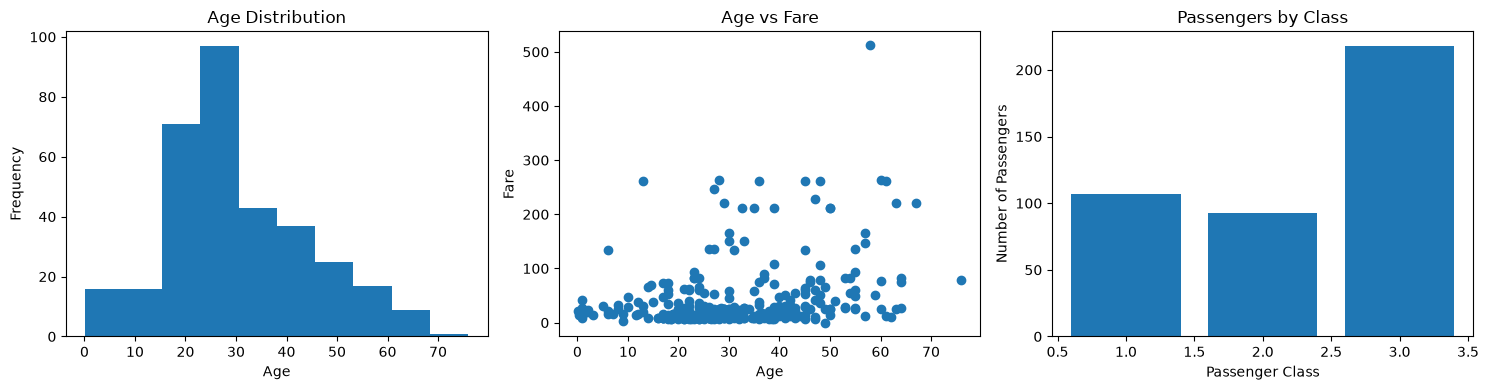

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram
axes[0].hist(df["Age"])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# 2. Scatter Plot
axes[1].scatter(df["Age"], df["Fare"])
axes[1].set_title("Age vs Fare")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Fare")

# 3. Bar Plot
class_counts = df["Pclass"].value_counts().sort_index()
axes[2].bar(class_counts.index, class_counts.values)
axes[2].set_title("Passengers by Class")
axes[2].set_xlabel("Passenger Class")
axes[2].set_ylabel("Number of Passengers")

plt.tight_layout()
plt.show()
